# Assignment 03 — Model Training
### Group Information

| Family name | First name | Email address |
| ----------- | ---------- | ------------- |
|             |            |               |
|             |            |               |
|             |            |               |




**Question 0: Add your Design Document on the flood use-case based on Lecture 1 below:**

**Answer:**

##### CONTEXT
Floods are responsible for some of the natural hazards affecting populations worldwide, accounting for around 41% of the natural hazards in the globe. In this context, having precise information about the areas that are affected at any given time is relevant for local authorities, journalists, and emergy respondents, whose task benefits immensely from having such information.

##### GOAL / NON-GOAL
Our goal is to build a Machine Learning model to detect floods using radar satellite imagery for informative purposes, using a web-based map (which can be printed for off-grid settings) as the medium. Moreover, we only focus on detecting large floods, and we specifically leave out of the scope of our project the detection of smaller, more localized floods. Similarly, we are not aiming at providing a forecast, it will not have a global scope (due to data availability constraints), it will not be updated daily, and it will not provide policy recommendations.

##### ASSUMPTIONS
- We need to establish some communication strategy between the user and ourselves, provided that the prediction will be made on-demand.
- The daily and global data availability constraints introduced by how satellites orbit the Earth pose a limitation. Therefore, we cannot offer a daily, global coverage.
- We use Synthetic Aperture Radar (SAR) imagery, provided that it can operate both day and night and under cloudy and rainy weather.

##### REQUIREMENTS
The map should identify the flooded pixels, as well as the surface affected (in hectares), the key infrastructure affected (including hospitals and government buildings), and provide an estimate of the people impacted and affected by the natural disaster.

Uncertainty at the pixel level should be reported to provide a measure of confidence in our prediction, in order for first responders to apply their field knowledge to each scenario they face.

The imagery that we will use has a resolution of 10 meters. We have selected this resolution because it strikes a balance between the cost and the desired level of disaggregation.

##### MEASURE OF SUCCESS
- On a technical level, the success of the model will be measured using the F1 score, and also by monitoring closely the false negatives.
- We will also measure the project's success by using satisfaction scores of the final users, which will ultimately signal whether the product is useful in real-life scenarios, and it is not only technically proficient.

##### RISK
- The offline work of first responders risks the feasibility of the product reaching its end user. This is why we propose providing a map to be printed (in pdf or in paper) for these situations.
- The limited budget we have is also a critical constraint.

## Step 0: Environment Setup



> **Setup Steps**
> 1. On the arrow on the bottom right, select **"Notebook Options"** → **"Accelerator"** → choose **GPU P100**, and select **"Variables & Files"** under Persistence.
> 2. Make sure your Kaggle account is phone verified by clicking **"Get phone verified"** in the left sidebar (required to enable internet access).
> 3. After phone verification, toggle the **"Internet"** switch in the full settings menu.
>
> More setup details: [StackOverflow guide](https://stackoverflow.com/questions/68142524/cannot-access-internet-on-kaggle-notebook)

> **⚠️ GPU Limit:** Kaggle provides **30h per week per user** of accelerated computing. Plan your work accordingly — data loading takes time and GPUs may be unavailable.

---

**Dataset Upload:**

1. Download the tiles: [ecti2021.zip](https://www.dropbox.com/scl/fi/tuvroadxyummourvx6cmz/ecti2021.zip?rlkey=wsc19sue84ytkphheptq28ica&st=9p8npaly&dl=0)
2. Go to the **"Side Bar"** → click **"Input"**
3. Upload as `ecti2021` the file `ecti2021.zip`, which contains: `train.zip`, `val_without_ref_labels.zip`, `water_tiles.csv`, and `background_tiles.csv` from `data_preparation.ipynb`.

In [1]:
# !uv pip install segmentation-models-pytorch
# ###!uv pip install -U git+https://github.com/albu/albumentations --no-cache-dir
# !uv add albumentations

# #Need to run in terminal
# #uv python pin 3.12

In [1]:
# load packages
import os
import sys
import cv2
import numpy as np
import pandas as pd
from glob import glob
import torch.nn as nn
from tqdm.notebook import tqdm
import matplotlib.pyplot as plt
import segmentation_models_pytorch as smp
# Set up plotting options
%matplotlib inline
import pickle
from pickle import load
import torch
from torch.utils.data import Dataset, DataLoader

/Users/joshuacastillo/Desktop/BSE_DSDM/T3/ImageDL/projects_applications_dl/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Load the dataset files

In [2]:
# Set path to where dataset is downloaded
dataset_root = 'ecti2021' #set accordingly based on how you uploaded the data
# get number of training/validation regions
train_dir = os.path.join(dataset_root, 'train/train')
test_dir = os.path.join(dataset_root, 'val_without_ref_labels/val')

n_train_regions = len(glob(train_dir+'/*/'))
n_test_regions = len(glob(test_dir+'/*/'))

# NOTE: make sure number of regions is NOT 0, otherwise it might be that the code is not able to read the data. 
print('Number of training temporal-regions: {}'.format(n_train_regions))
print('Number of test temporal-regions: {}'.format(n_test_regions))

Number of training temporal-regions: 31
Number of test temporal-regions: 10


> **Note:** From `Lab_01_data_preparation`, the ETCI 2021 Competition contains **33,405 tiles** in total. After removing tiles with empty VV/VH images but non-zero labels, the cleaned dataset used here contains **27,214 tiles**.

### Utils functions

In [7]:
def visualize(df_row, figsize=[25, 15]):
    # get image paths
    vv_image_path = df_row['vv_image_path']
    vh_image_path = df_row['vh_image_path']
    flood_label_path = df_row['flood_label_path']
    water_body_label_path = df_row['water_body_label_path']

    # create RGB image from S1 images
    rgb_name = get_filename(vv_image_path)
    vv_image = cv2.imread(vv_image_path, 0) / 255.0
    vh_image = cv2.imread(vh_image_path, 0) / 255.0
    rgb_image = s1_to_rgb(vv_image, vh_image)

    # get water body label mask
    water_body_label_image = cv2.imread(water_body_label_path, 0) / 255.0

    # plot images
    plt.figure(figsize=tuple(figsize))
    if df_row.isnull().sum() > 0:
        # plot RGB S1 image
        plt.subplot(1,2,1)
        plt.imshow(rgb_image)
        plt.title(rgb_name)

        # plot water body mask
        plt.subplot(1,2,2)
        plt.imshow(water_body_label_image)
        plt.title('Water body mask')
    else:
        flood_label_image = cv2.imread(flood_label_path, 0) / 255.0
        # plot RGB S1 image
        plt.subplot(1,3,1)
        plt.imshow(rgb_image)
        plt.title(rgb_name)

        # plot flood label mask
        plt.subplot(1,3,2)
        plt.imshow(flood_label_image)
        plt.title('Flood mask')

        # plot water body mask
        plt.subplot(1,3,3)
        plt.imshow(water_body_label_image)
        plt.title('Water body mask')

def s1_to_rgb(vv_image, vh_image):
    eps=1e-06
    ratio_image = np.clip(np.nan_to_num(vv_image/(vh_image+eps), 0), 0, 1) # outside [0,1] will be clipped
    rgb_image = np.stack((vv_image, vh_image, ratio_image), axis=2) #different from lab01: np.abs(red) / np.abs(green) 
    return rgb_image

def visualize_result(df_row, prediction, figsize=[25, 15]):
    vv_image = cv2.imread(df_row['vv_image_path'], 0) / 255.0
    vh_image = cv2.imread(df_row['vh_image_path'], 0) / 255.0
    rgb_input = s1_to_rgb(vv_image, vh_image)

    plt.figure(figsize=tuple(figsize))
    plt.subplot(1,2,1)
    plt.imshow(rgb_input)
    plt.title('RGB w/ result')
    plt.subplot(1,2,2)
    plt.imshow(prediction)
    plt.title('Result')

## Create training dataframes

In [8]:
def get_filename(filepath,split_symbol='/'):
    return filepath.split(split_symbol)[-1]

def read_csv(csvpath,split_symbol='\\'):
    path_list = np.loadtxt(csvpath,delimiter=" ", dtype=str).tolist()
    return [get_filename(pth,split_symbol) for pth in path_list]

In [9]:
water_image_names = read_csv('ecti2021/water_tiles.csv') #from lab01 make sure the path is correct
background_image_names = read_csv('ecti2021/background_tiles.csv')

region_name_dates0 = ['_'.join(n.split('_')[:2]) for n in water_image_names]
region_name_dates1 = ['_'.join(n.split('_')[:2]) for n in background_image_names]

vv_image_paths, vh_image_paths, flood_label_paths, water_body_label_paths = [], [], [], []


water_image_paths,background_image_paths = [],[]

for i in range(len(water_image_names)):
    vv_image_path = os.path.join(train_dir, region_name_dates0[i], 'tiles', 'vv', water_image_names[i])
    vv_image_paths.append(vv_image_path)
    water_image_paths.append(vv_image_path)
    
    # get vh image path
    vh_image_name = water_image_names[i].replace('vv', 'vh')
    vh_image_path = os.path.join(train_dir, region_name_dates0[i], 'tiles', 'vh', vh_image_name)
    vh_image_paths.append(vh_image_path)

    # get flood mask path
    flood_image_name = water_image_names[i].replace('_vv', '')
    flood_label_path = os.path.join(train_dir, region_name_dates0[i], 'tiles', 'flood_label', flood_image_name)
    flood_label_paths.append(flood_label_path)

    # get water body mask path
    water_body_label_name = water_image_names[i].replace('_vv', '')
    water_body_label_path = os.path.join(train_dir, region_name_dates0[i], 'tiles', 'water_body_label', water_body_label_name)
    water_body_label_paths.append(water_body_label_path)
    
for i in range(len(background_image_names)):
    vv_image_path = os.path.join(train_dir, region_name_dates1[i], 'tiles', 'vv', background_image_names[i])
    vv_image_paths.append(vv_image_path)
    background_image_paths.append(vv_image_path)
    
    # get vh image path
    vh_image_name = background_image_names[i].replace('vv', 'vh')
    vh_image_path = os.path.join(train_dir, region_name_dates1[i], 'tiles', 'vh', vh_image_name)
    vh_image_paths.append(vh_image_path)

    # get flood mask path
    flood_image_name = background_image_names[i].replace('_vv', '')
    flood_label_path = os.path.join(train_dir, region_name_dates1[i], 'tiles', 'flood_label', flood_image_name)
    flood_label_paths.append(flood_label_path)

    # get water body mask path
    water_body_label_name = background_image_names[i].replace('_vv', '')
    water_body_label_path = os.path.join(train_dir, region_name_dates1[i], 'tiles', 'water_body_label', water_body_label_name)
    water_body_label_paths.append(water_body_label_path)
    

In [10]:
#Shuffle the index and then split in train and validation
n=len(vv_image_paths) #number of images in the dataset
arr = np.arange(n) #array 0...n-1
np.random.shuffle(arr) # shuffle it
train_idx=arr[0:int(np.round(0.80*n))] #80% train
valid_idx=arr[int(np.round(0.80*n)):] #20% validation
print("Number of tiles in training set:",train_idx.size)
print("Number of tiles in validation set:",valid_idx.size)
print("Number of tiles in the training and validation set:",train_idx.size+valid_idx.size) 

Number of tiles in training set: 21771
Number of tiles in validation set: 5443
Number of tiles in the training and validation set: 27214


In [11]:
vv_image_paths_train = list(np.array(vv_image_paths)[train_idx])
vh_image_paths_train = list(np.array(vh_image_paths)[train_idx])
flood_label_paths_train = list(np.array(flood_label_paths)[train_idx])
water_body_label_paths_train = list(np.array(water_body_label_paths)[train_idx])

train_paths = {'vv_image_path': vv_image_paths_train,
        'vh_image_path': vh_image_paths_train,
        'flood_label_path': flood_label_paths_train,
        'water_body_label_path': water_body_label_paths_train,
}

train_df = pd.DataFrame(train_paths)

print(train_df.shape)
train_df.head()

(21771, 4)


,vv_image_path,vh_image_path,flood_label_path,water_body_label_path
0,ecti2021/train/train/northal_20190910t234659/t...,ecti2021/train/train/northal_20190910t234659/t...,ecti2021/train/train/northal_20190910t234659/t...,ecti2021/train/train/northal_20190910t234659/t...
1,ecti2021/train/train/nebraska_20170520t002113/...,ecti2021/train/train/nebraska_20170520t002113/...,ecti2021/train/train/nebraska_20170520t002113/...,ecti2021/train/train/nebraska_20170520t002113/...
2,ecti2021/train/train/northal_20190630t234655/t...,ecti2021/train/train/northal_20190630t234655/t...,ecti2021/train/train/northal_20190630t234655/t...,ecti2021/train/train/northal_20190630t234655/t...
3,ecti2021/train/train/northal_20190630t234655/t...,ecti2021/train/train/northal_20190630t234655/t...,ecti2021/train/train/northal_20190630t234655/t...,ecti2021/train/train/northal_20190630t234655/t...
4,ecti2021/train/train/northal_20191004t234700/t...,ecti2021/train/train/northal_20191004t234700/t...,ecti2021/train/train/northal_20191004t234700/t...,ecti2021/train/train/northal_20191004t234700/t...


In [12]:
vv_image_paths_valid = list(np.array(vv_image_paths)[valid_idx])
vh_image_paths_valid = list(np.array(vh_image_paths)[valid_idx])
flood_label_paths_valid = list(np.array(flood_label_paths)[valid_idx])
water_body_label_paths_valid = list(np.array(water_body_label_paths)[valid_idx])

valid_paths = {'vv_image_path': vv_image_paths_valid,
        'vh_image_path': vh_image_paths_valid,
        'flood_label_path': flood_label_paths_valid,
        'water_body_label_path': water_body_label_paths_valid,
}


valid_df = pd.DataFrame(valid_paths)

print(valid_df.shape)
valid_df.head()

(5443, 4)


,vv_image_path,vh_image_path,flood_label_path,water_body_label_path
0,ecti2021/train/train/nebraska_20170108t002112/...,ecti2021/train/train/nebraska_20170108t002112/...,ecti2021/train/train/nebraska_20170108t002112/...,ecti2021/train/train/nebraska_20170108t002112/...
1,ecti2021/train/train/northal_20190302t234651/t...,ecti2021/train/train/northal_20190302t234651/t...,ecti2021/train/train/northal_20190302t234651/t...,ecti2021/train/train/northal_20190302t234651/t...
2,ecti2021/train/train/nebraska_20170213t002121/...,ecti2021/train/train/nebraska_20170213t002121/...,ecti2021/train/train/nebraska_20170213t002121/...,ecti2021/train/train/nebraska_20170213t002121/...
3,ecti2021/train/train/northal_20190525t234653/t...,ecti2021/train/train/northal_20190525t234653/t...,ecti2021/train/train/northal_20190525t234653/t...,ecti2021/train/train/northal_20190525t234653/t...
4,ecti2021/train/train/nebraska_20171222t002118/...,ecti2021/train/train/nebraska_20171222t002118/...,ecti2021/train/train/nebraska_20171222t002118/...,ecti2021/train/train/nebraska_20171222t002118/...


## Create training undersampled dataframes

In [13]:
background_image_paths_train = [path for path in background_image_paths if path in vv_image_paths_train]
background_num_train = len(background_image_paths_train)
print('Number of background tiles included in training:',background_num_train)

water_image_paths_train = [path for path in water_image_paths if path in vv_image_paths_train]
water_image_names_train = [get_filename(pth) for pth in water_image_paths_train]
region_name_dates2 = ['_'.join(n.split('_')[:2]) for n in water_image_names_train]
water_num_train = len(water_image_paths_train)
print('Number of water tiles included in training:',water_num_train)

Number of background tiles included in training: 13362
Number of water tiles included in training: 8409


In [14]:
num_samples = int(water_num_train * 0.15) #include 15% of water tiles
arr = np.arange(int(water_num_train * 0.15))  # array 0...n-1
np.random.shuffle(arr)  # shuffle it
background_image_paths_train_undersampled = list(np.array(background_image_paths_train)[arr[0:num_samples]])
background_image_names_train_undersampled = [get_filename(pth) for pth in background_image_paths_train_undersampled]
print('Number of background tiles included in training after undersampling:',len(background_image_names_train_undersampled))
region_name_dates3 = ['_'.join(n.split('_')[:2]) for n in background_image_names_train_undersampled]

vh_image_paths_train_undersampled, flood_label_paths_train_undersampled, water_body_label_paths_train_undersampled = [], [], []
for i in range(len(water_image_names_train)):
    # get vh image path
    vh_image_name = water_image_names_train[i].replace('vv', 'vh')
    vh_image_path = os.path.join(train_dir, region_name_dates2[i], 'tiles', 'vh', vh_image_name)
    vh_image_paths_train_undersampled.append(vh_image_path)

    # get flood mask path
    flood_image_name = water_image_names_train[i].replace('_vv', '')
    flood_label_path = os.path.join(train_dir, region_name_dates2[i], 'tiles', 'flood_label', flood_image_name)
    flood_label_paths_train_undersampled.append(flood_label_path)

    # get water body mask path
    water_body_label_name = water_image_names_train[i].replace('_vv', '')
    water_body_label_path = os.path.join(train_dir, region_name_dates2[i], 'tiles', 'water_body_label', water_body_label_name)
    water_body_label_paths_train_undersampled.append(water_body_label_path)

vv_image_paths_train_undersampled = water_image_paths_train
print('Number of water body label included in training after undersampling:',len(water_body_label_paths_train_undersampled))
for i in range(len(background_image_names_train_undersampled)):
    vv_image_paths_train_undersampled.append(background_image_paths_train_undersampled[i])
    
    # get vh image path
    vh_image_name = background_image_names_train_undersampled[i].replace('vv', 'vh')
    vh_image_path = os.path.join(train_dir, region_name_dates3[i], 'tiles', 'vh', vh_image_name)
    vh_image_paths_train_undersampled.append(vh_image_path)

    # get flood mask path
    flood_image_name = background_image_names_train_undersampled[i].replace('_vv', '')
    flood_label_path = os.path.join(train_dir, region_name_dates3[i], 'tiles', 'flood_label', flood_image_name)
    flood_label_paths_train_undersampled.append(flood_label_path)

    # get water body mask path
    water_body_label_name = background_image_names_train_undersampled[i].replace('_vv', '')
    water_body_label_path = os.path.join(train_dir, region_name_dates3[i], 'tiles', 'water_body_label', water_body_label_name)
    water_body_label_paths_train_undersampled.append(water_body_label_path)
assert len(vv_image_paths_train_undersampled)==len(vh_image_paths_train_undersampled)==len(flood_label_paths_train_undersampled)==len(water_body_label_paths_train_undersampled)
print('Number of overall images  included in training after undersampling:',len(water_body_label_paths_train_undersampled))

Number of background tiles included in training after undersampling: 1261
Number of water body label included in training after undersampling: 8409
Number of overall images  included in training after undersampling: 9670


In [15]:
train_paths_undersample = {'vv_image_path': vv_image_paths_train_undersampled,
        'vh_image_path': vh_image_paths_train_undersampled,
        'flood_label_path': flood_label_paths_train_undersampled,
        'water_body_label_path': water_body_label_paths_train_undersampled
}
train_df_undersample = pd.DataFrame(train_paths_undersample)

print(train_df_undersample.shape)
train_df_undersample.head() 

(9670, 4)


,vv_image_path,vh_image_path,flood_label_path,water_body_label_path
0,ecti2021/train/train/bangladesh_20170314t11560...,ecti2021/train/train/bangladesh_20170314t11560...,ecti2021/train/train/bangladesh_20170314t11560...,ecti2021/train/train/bangladesh_20170314t11560...
1,ecti2021/train/train/bangladesh_20170314t11560...,ecti2021/train/train/bangladesh_20170314t11560...,ecti2021/train/train/bangladesh_20170314t11560...,ecti2021/train/train/bangladesh_20170314t11560...
2,ecti2021/train/train/bangladesh_20170314t11560...,ecti2021/train/train/bangladesh_20170314t11560...,ecti2021/train/train/bangladesh_20170314t11560...,ecti2021/train/train/bangladesh_20170314t11560...
3,ecti2021/train/train/bangladesh_20170314t11560...,ecti2021/train/train/bangladesh_20170314t11560...,ecti2021/train/train/bangladesh_20170314t11560...,ecti2021/train/train/bangladesh_20170314t11560...
4,ecti2021/train/train/bangladesh_20170314t11560...,ecti2021/train/train/bangladesh_20170314t11560...,ecti2021/train/train/bangladesh_20170314t11560...,ecti2021/train/train/bangladesh_20170314t11560...


**Question 1 —** Based on the considerations from Lab 1 and the calculation above, explain the original dataset in terms of class imbalance and how this changed in the undersampled dataset.

**Answer:** In the original dataset, 67.3% of the tiles were background tiles, and 32.7% were water tiles. Notice how there was a class imbalance, provided that there were roughly 50% less water tiles when compared to background tiles. However, the background tiles are generally less informative since they do not contain any relevant information. The great amount of background tiles can be likened to noise. By undersampling the background class, we address this imbalance not by eliminating it altogether, but rather by introducing a massive class imbalance in the other direction for signals that matter more, which are water tiles. Provided that we want our model to pick up on changes in tiles with water, we decrease the share of background tiles up to the point that represent about 7 times the share of background tiles. This leaves sufficient background tiles to remain contrastive but not make the model learn any pattern in this irrelevant noise, which it may have prioritized predicting the first time around in the full dataset.

## Visualize images

This section is meant to be used to experiment with the data. Feel free to change things and explore.

In [16]:
train_df

,vv_image_path,vh_image_path,flood_label_path,water_body_label_path
0,ecti2021/train/train/northal_20190910t234659/t...,ecti2021/train/train/northal_20190910t234659/t...,ecti2021/train/train/northal_20190910t234659/t...,ecti2021/train/train/northal_20190910t234659/t...
1,ecti2021/train/train/nebraska_20170520t002113/...,ecti2021/train/train/nebraska_20170520t002113/...,ecti2021/train/train/nebraska_20170520t002113/...,ecti2021/train/train/nebraska_20170520t002113/...
2,ecti2021/train/train/northal_20190630t234655/t...,ecti2021/train/train/northal_20190630t234655/t...,ecti2021/train/train/northal_20190630t234655/t...,ecti2021/train/train/northal_20190630t234655/t...
3,ecti2021/train/train/northal_20190630t234655/t...,ecti2021/train/train/northal_20190630t234655/t...,ecti2021/train/train/northal_20190630t234655/t...,ecti2021/train/train/northal_20190630t234655/t...
4,ecti2021/train/train/northal_20191004t234700/t...,ecti2021/train/train/northal_20191004t234700/t...,ecti2021/train/train/northal_20191004t234700/t...,ecti2021/train/train/northal_20191004t234700/t...
...,...,...,...,...
21766,ecti2021/train/train/nebraska_20170929t002120/...,ecti2021/train/train/nebraska_20170929t002120/...,ecti2021/train/train/nebraska_20170929t002120/...,ecti2021/train/train/nebraska_20170929t002120/...
21767,ecti2021/train/train/nebraska_20170929t002120/...,ecti2021/train/train/nebraska_20170929t002120/...,ecti2021/train/train/nebraska_20170929t002120/...,ecti2021/train/train/nebraska_20170929t002120/...
21768,ecti2021/train/train/northal_20190302t234651/t...,ecti2021/train/train/northal_20190302t234651/t...,ecti2021/train/train/northal_20190302t234651/t...,ecti2021/train/train/northal_20190302t234651/t...
21769,ecti2021/train/train/northal_20191227t234659/t...,ecti2021/train/train/northal_20191227t234659/t...,ecti2021/train/train/northal_20191227t234659/t...,ecti2021/train/train/northal_20191227t234659/t...


In [17]:
cv2.imread(train_df_undersample.iloc[1200]['vv_image_path'],0)

array([[137, 131, 126, ..., 174, 170, 172],
       [131, 115, 113, ..., 167, 164, 167],
       [114, 104, 108, ..., 159, 157, 165],
       ...,
       [125, 139, 152, ..., 172, 170, 169],
       [112, 137, 159, ..., 172, 169, 162],
       [104, 129, 166, ..., 176, 170, 162]], shape=(256, 256), dtype=uint8)

In [18]:
train_df_undersample.iloc[3600]['vv_image_path']

'ecti2021/train/train/northal_20190302t234651/tiles/vv/northal_20190302t234651_x-8_y-22_vv.png'

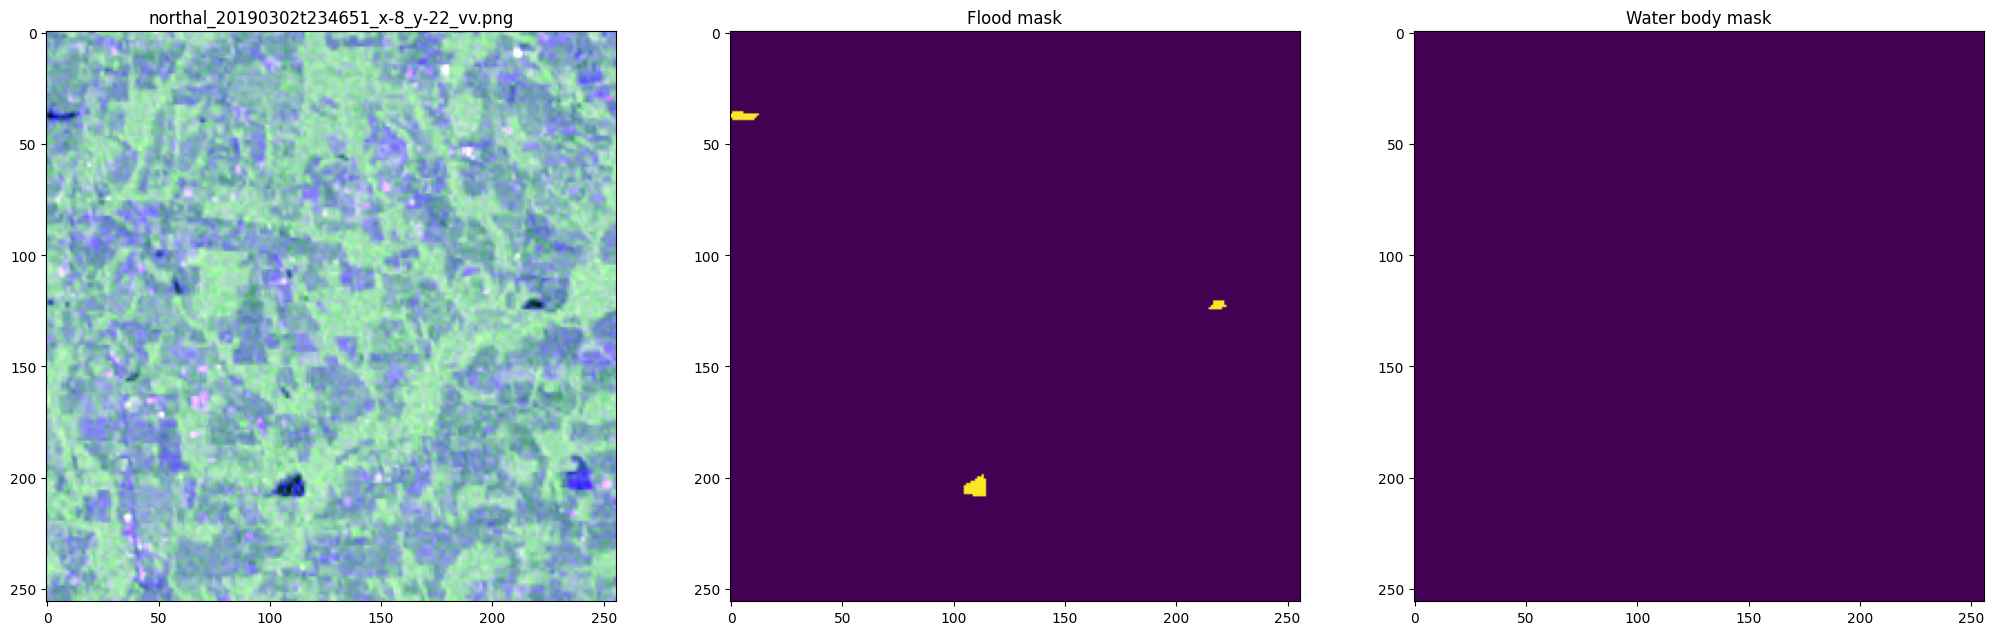

In [19]:
visualize(train_df_undersample.iloc[3600])

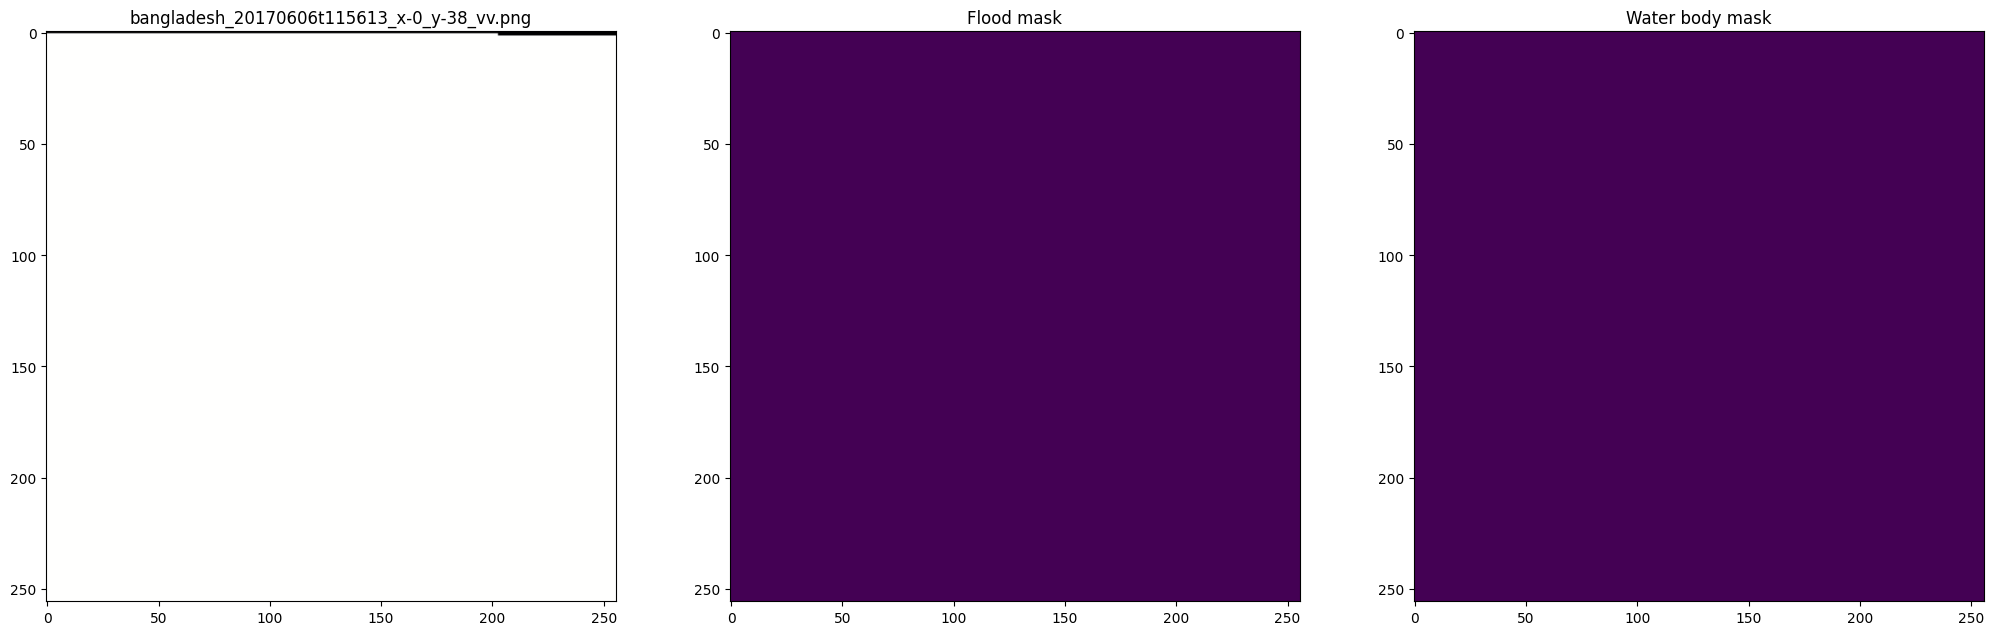

In [20]:
visualize(train_df.iloc[3677])

## Setup the dataset for machine learning

Since Phase 1 of the ETCI 2021 Competition provides training data (with reference labels) and validation data (without reference labels until Phase 1 concludes), we will split our training dataset into a smaller training and development set.

### Create a PyTorch dataset

We will use the **PyTorch** deep learning library to format the dataset and build the model. This requires a custom `Dataset` class passed into a `DataLoader` object — see the [PyTorch Dataset Tutorial](https://pytorch.org/tutorials/beginner/data_loading_tutorial.html) for details. Image transformations will be computed using the [Albumentations](https://github.com/albumentations-team/albumentations) package.

**Question 2 —** Implement an `ETCIDataset` class.

In [21]:
import cv2
import numpy as np
import torch
from torch.utils.data import Dataset
import albumentations as A
from albumentations.pytorch import ToTensorV2
import os # Added to verify file existence

class ETCIDataset(Dataset):
    def __init__(self, df, mask_col='water_body_label_path', transform=None):
        self.df = df.reset_index(drop=True)
        self.mask_col = mask_col
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        
        # FIX 1: Check if file exists. cv2.imread returns None silently if path is wrong.
        def load_img(path):
            img = cv2.imread(path, cv2.IMREAD_GRAYSCALE)
            if img is None:
                raise FileNotFoundError(f"Image not found or empty at: {path}")
            return img.astype(np.float32) / 255.0

        vv_image = load_img(row['vv_image_path'])
        vh_image = load_img(row['vh_image_path'])
        
        # 2. Create the 3-channel input
        eps = 1e-06
        ratio_image = np.clip(np.nan_to_num(vv_image / (vh_image + eps), nan=0.0, posinf=1.0, neginf=0.0), 0, 1)
        
        image = np.stack((vv_image, vh_image, ratio_image), axis=2)

        # 3. Load the mask
        mask = cv2.imread(row[self.mask_col], cv2.IMREAD_GRAYSCALE)
        if mask is None:
            raise FileNotFoundError(f"Mask not found at: {row[self.mask_col]}")
        
        # Keep mask as uint8 (0-255) for Albumentations to avoid interpolation artifacts
        # Binarize it if needed, but do it after transforms or explicitly here.
        mask = (mask > 127).astype(np.uint8)

        # 4. Apply Albumentations
        if self.transform is not None:
            augmented = self.transform(image=image, mask=mask)
            image = augmented['image']
            mask = augmented['mask']
        else:
            # If no transform, manually convert image to tensor (C, H, W)
            image = torch.from_numpy(image.transpose(2, 0, 1))
            mask = torch.from_numpy(mask)

        # 5. Ensure mask has channel dimension (1, H, W)
        if mask.dim() == 2:
            mask = mask.unsqueeze(0)
            
        # Ensure mask is float32 for BCEWithLogitsLoss
        return image, mask.float()

**Question 3 —** Implement a data augmentation pipeline appropriate for Sentinel-1 SAR imagery.

Things to consider:
- SAR images are not optical — which standard augmentations from natural image datasets **do not apply** and why?
- Which geometric augmentations are physically valid for radar backscatter images?
- Justify each augmentation you include.

Then load the train and validation datasets using your chosen transform.

SAR Data Augmentation Analysis
1. Which standard optical augmentations do not apply and why?
Standard photometric augmentations designed for natural optical images—such as ColorJitter, HueSaturationValue, RandomBrightnessContrast, RGBShift, or CLAHE—should not be used on SAR data.

-  Reasoning: Optical images capture reflected sunlight in the visible spectrum, where brightness and color vary based on time of day, shadows, and camera sensors. SAR is an active microwave sensor. The pixel values represent physical backscatter (usually measured as Sigma-nought, $\sigma^0$, representing surface roughness and dielectric properties). Arbitrarily shifting the "brightness" or "hue" mathematically destroys the physical integrity of the radar cross-section measurements. Additionally, applying standard Gaussian blur or noise can disrupt the natural speckle statistics inherent to SAR imagery.

2. Which geometric augmentations are physically valid for radar backscatter images?
Orthogonal geometric transformations that do not require pixel interpolation are the most valid.
- Valid: HorizontalFlip, VerticalFlip, RandomRotate90, and Transpose.
- Invalid/Risky: Rotate (with arbitrary angles like 45°), ElasticTransform, or GridDistortion. Interpolation alters the raw backscatter values and the distribution of speckle noise, which can confuse the model. Furthermore, SAR backscatter can be directionally dependent (e.g., urban structures cause dihedral reflections from specific look angles), but for general land cover, orthogonal flips and rotations are safe.

3. Justification for the chosen pipeline:
- A.HorizontalFlip(p=0.5) & A.VerticalFlip(p=0.5): Safely increases spatial diversity without altering the radiometric values or requiring interpolation.
- A.RandomRotate90(p=0.5): Provides further rotational invariance (useful for natural features like flood extents, forests, or water bodies) while keeping the pixel grid intact.
- ToTensorV2(): A mandatory PyTorch conversion. (Note: Unlike optical datasets, you should not use ImageNet's Normalize here. If you need normalization, it should be calculated specifically from your SAR dataset's global statistics).

In [22]:
import albumentations as A
from albumentations.pytorch import ToTensorV2

### BEGINNING OF THE CODE

# 1. Define the training transform (with valid SAR augmentations)
train_transform = A.Compose([
    A.HorizontalFlip(p=0.5),
    A.VerticalFlip(p=0.5),
    A.RandomRotate90(p=0.5),
    ToTensorV2()
])

# Define the validation transform (strictly to tensor, no random augmentations)
valid_transform = A.Compose([
    ToTensorV2()
])

# Instantiate the datasets using the newly updated ETCIDataset class
train_dataset = ETCIDataset(
    df=train_df_undersample, 
    mask_col='water_body_label_path', # Change to 'flood_label_path' when predicting floods
    transform=train_transform
)

valid_dataset = ETCIDataset(
    df=valid_df, 
    mask_col='water_body_label_path', 
    transform=valid_transform
)

#### END OF THE CODE

print('Training set size:', len(train_dataset))
print('Validation set size:', len(valid_dataset))

Training set size: 9670
Validation set size: 5443


In [23]:
batch_size = 64

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=0, pin_memory=True)
valid_loader = DataLoader(valid_dataset, batch_size=batch_size, shuffle=False, num_workers=0, pin_memory=True)

In [24]:
train_undersampled_dataset = ETCIDataset(train_df_undersample, mask_col='water_body_label_path', transform=train_transform)
train_undersampled_loader = DataLoader(train_undersampled_dataset, batch_size=batch_size, shuffle=True, num_workers=0, pin_memory=True)
print('Undersampled Trainining set size:',len(train_undersampled_dataset))

Undersampled Trainining set size: 9670


## Deep learning model creation

In [25]:
device = 'mps' 

**Question 4 —** Choose and implement a segmentation model from the [Segmentation Models](https://github.com/qubvel/segmentation_models.pytorch) package.

In your answer:
- **Justify your encoder choice** — why this architecture over others?
- **Justify your pretrained weights decision** — should you use ImageNet weights for SAR imagery? What is the domain gap and does transfer learning still help?
- **State the number of input channels and output classes** and explain why.

**Answer:**

1. Justify your encoder choice
A strong, reliable choice for this task is ResNet-34 (paired with a U-Net architecture).
- Why: ResNet-34 strikes an excellent balance between feature extraction capabilities and computational efficiency. Since we are working with an undersampled dataset and limited GPU hours on Kaggle, a massive encoder (like ResNet-101 or EfficientNet-B7) would be prone to overfitting and slow to train. The residual connections in ResNet-34 allow it to learn deep spatial representations (vital for mapping continuous water bodies) without the vanishing gradient problem.

2. Justify your pretrained weights decision
We should use ImageNet pretrained weights, despite the obvious domain gap.
- The Domain Gap: ImageNet consists of natural, optical 3-band (RGB) images of everyday objects (dogs, cars, etc.). SAR data consists of single-channel microwave backscatter arrays affected by speckle noise, varying dielectric properties, and distinct geometry.
- Why transfer learning still helps: Deep convolutional networks learn hierarchically. The earliest layers of an ImageNet-trained encoder act as generic edge, corner, and texture detectors (similar to Gabor filters). These low-level spatial feature extractors are universally useful across almost all image types, including SAR. Initializing with ImageNet weights consistently leads to much faster convergence and often better final performance than starting from scratch (random initialization), even for radar imagery.

3. State the number of input channels and output classes
- Input Channels: 3. Even though Sentinel-1 only provides two polarizations here (VV and VH), our ETCIDataset uses the s1_to_rgb logic to calculate a third channel (the VV / VH ratio). Stacking these into a 3-channel input serves two purposes: it provides more relational data to the model, and it strictly aligns with the 3-channel structure expected by ImageNet-pretrained encoders.
- Output Classes: 1. We are performing binary segmentation (predicting whether a pixel is "Water" / "Flood" or "Background"). For binary tasks, it is computationally most efficient to output a single channel (yielding values between 0 and 1 after a Sigmoid activation) rather than two separate mutually exclusive channels.

In [26]:
import torch
import segmentation_models_pytorch as smp

def create_model():
    """
    Initializes the U-Net segmentation model with a ResNet-34 encoder 
    and ImageNet pretrained weights.
    """
    # Define the model architecture
    model = smp.Unet(
        encoder_name="resnet34",        # Choose the architecture (ResNet-34)
        encoder_weights="imagenet",     # Use pretrained weights to speed up convergence
        in_channels=3,                  # VV, VH, and VV/VH ratio
        classes=2,                      # Binary segmentation (1 for water/flood, 0 for background)
    )

    # Move the model to the GPU if available
    device = torch.device('mps' if torch.mps.is_available() else 'cpu')
    model = model.to(device)
    
    print(f"Model successfully created and loaded on: {device}")
    
    return model

In [24]:
model_1 = create_model()
model_1.to(device) # load model into GPU memory

Model successfully created and loaded on: mps


Unet(
  (encoder): ResNetEncoder(
    (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (relu): ReLU(inplace=True)
    (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
    (layer1): Sequential(
      (0): BasicBlock(
        (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
        (relu): ReLU(inplace=True)
        (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
      )
      (1): BasicBlock(
        (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05,

### Metric tracker

In [29]:
from sklearn.metrics import confusion_matrix

class EvalTracker:
    def __init__(self, n_classes=2, smooth=0.0001):
        self.n_classes = n_classes
        self.reset()
        self.smooth = smooth

    def reset(self):
        self.cm = np.zeros((self.n_classes, self.n_classes))
        self.count = 0
    
    def update(self, pred, target):
        # pred: [B, 2, H, W]
        # target: [B, H, W]
        self.count += pred.shape[0]

        # reshape inputs
        pred = pred.argmax(dim=1).flatten()  # [B*H*W]
        target = target.flatten()  # [B*H*W]

        # put into cpu memory
        pred = pred.detach().cpu().numpy()
        target = target.detach().cpu().numpy()

        # compute confusion matrix values
        self.cm += confusion_matrix(target, pred)

    def get_mean(self):
        tn, fp, fn, tp = self.cm.ravel()

        # compute IoU
        iou = tp / (tp + fp + fn + self.smooth)
        prec = tp / (tp + fp + self.smooth)
        rec = tp / (tp + fn + self.smooth)
        f1 = 2.0*prec*rec/(prec+rec)

        return iou, prec, rec, f1


## Train model on the full dataset

### Model config, optimizer and loss function

In [26]:
# set the number of times you want the model to see all of the training data
epochs = 5
learning_rate = 1e-4
optimizer = torch.optim.Adam(model_1.parameters(), lr=learning_rate)
criteria_no_weights = nn.CrossEntropyLoss(weight=None)

### Training Loop

**Question 5 —** Train the model and plot training and validation loss.

In [32]:
import torch.optim as optim
import torch.nn as nn
from tqdm import tqdm
from torch.utils.data import DataLoader
import segmentation_models_pytorch as smp

# 1. Initialize Loaders, Model, Loss, Optimizer, Tracker
batch_size = 32
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=0, pin_memory=True)
valid_loader = DataLoader(valid_dataset, batch_size=batch_size, shuffle=False, num_workers=0, pin_memory=True)

device = torch.device("mps" if torch.backends.mps.is_available() else "cuda" if torch.cuda.is_available() else "cpu")
    
model = create_model().to(device)
criterion = nn.CrossEntropyLoss() # Assuming 'weights' is defined
optimizer = optim.Adam(model.parameters(), lr=1e-4)

tracker = EvalTracker(n_classes=2)

# 2. Training Parameters & Saving Config
epochs = 5
best_valid_f1 = 0.0
model_save_path = "model1.pth"
train_losses, valid_losses, valid_f1_scores = [], [], []

print(f"Starting training on {device} for {epochs} epochs...")

for epoch in range(epochs):
    # --- TRAINING PHASE ---
    model.train()
    running_train_loss = 0.0
    train_bar = tqdm(train_loader, desc=f'Epoch {epoch+1}/{epochs} [Train]')
    for images, masks in train_bar:
        images, masks = images.to(device), masks.to(device)
        target = masks.long().squeeze(1)
        
        optimizer.zero_grad()
        outputs = model(images) 
        loss = criterion(outputs, target)
        loss.backward()
        optimizer.step()
        
        running_train_loss += loss.item() * images.size(0)
        train_bar.set_postfix({'loss': loss.item()})
        
    train_losses.append(running_train_loss / len(train_loader.dataset))
    
    # --- VALIDATION PHASE ---
    model.eval()
    running_valid_loss = 0.0
    tracker.reset()
    
    valid_bar = tqdm(valid_loader, desc=f'Epoch {epoch+1}/{epochs} [Valid]')
    with torch.no_grad():
        for images, masks in valid_bar:
            images, masks = images.to(device), masks.to(device)
            target = masks.long().squeeze(1)
            
            outputs = model(images) 
            loss = criterion(outputs, target)
            running_valid_loss += loss.item() * images.size(0)
            
            tracker.update(outputs, target)
            valid_bar.set_postfix({'loss': loss.item()})

    # Get metrics
    iou, prec, rec, f1 = tracker.get_mean()
    
    # Store them
    valid_losses.append(running_valid_loss / len(valid_loader.dataset))
    valid_f1_scores.append(f1)
    
    print(f"Epoch {epoch+1}/{epochs} | F1: {f1:.4f} | IoU: {iou:.4f}\n")
    
    # --- BEST MODEL SAVING ---
    if f1 > best_valid_f1:
        best_valid_f1 = f1
        torch.save(model.to('cpu').state_dict(), model_save_path)
        model.to(device)
        print(f"Validation F1 improved to {best_valid_f1:.4f}. Model saved to {model_save_path}\n")

Model successfully created and loaded on: mps
Starting training on mps for 5 epochs...


Epoch 1/5 [Train]:   0%|          | 0/299 [00:00<?, ?it/s]/Users/joshuacastillo/Desktop/BSE_DSDM/T3/ImageDL/projects_applications_dl/.venv/lib/python3.12/site-packages/torch/utils/data/dataloader.py:752: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)
Epoch 1/5 [Valid]: 100%|██████████| 171/171 [00:52<00:00,  3.23it/s, loss=0.0379]


Epoch 1/5 | F1: 0.7186 | IoU: 0.5607

Validation F1 improved to 0.7186. Model saved to model1.pth



Epoch 2/5 [Train]:   0%|          | 0/299 [00:00<?, ?it/s]/Users/joshuacastillo/Desktop/BSE_DSDM/T3/ImageDL/projects_applications_dl/.venv/lib/python3.12/site-packages/torch/utils/data/dataloader.py:752: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)
Epoch 2/5 [Valid]: 100%|██████████| 171/171 [00:51<00:00,  3.32it/s, loss=0.0161]


Epoch 2/5 | F1: 0.7662 | IoU: 0.6211

Validation F1 improved to 0.7662. Model saved to model1.pth



...

Epoch 3/5 | F1: 0.7879 | IoU: 0.6500

Validation F1 improved to 0.7879. Model saved to model1.pth



Epoch 4/5 [Train]:   0%|          | 0/299 [00:00<?, ?it/s]/Users/joshuacastillo/Desktop/BSE_DSDM/T3/ImageDL/projects_applications_dl/.venv/lib/python3.12/site-packages/torch/utils/data/dataloader.py:752: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)
Epoch 4/5 [Valid]: 100%|██████████| 171/171 [00:51<00:00,  3.30it/s, loss=0.0085] 


Epoch 4/5 | F1: 0.8012 | IoU: 0.6683

Validation F1 improved to 0.8012. Model saved to model1.pth



Epoch 5/5 [Train]:   0%|          | 0/299 [00:00<?, ?it/s]/Users/joshuacastillo/Desktop/BSE_DSDM/T3/ImageDL/projects_applications_dl/.venv/lib/python3.12/site-packages/torch/utils/data/dataloader.py:752: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)
Epoch 5/5 [Valid]: 100%|██████████| 171/171 [00:52<00:00,  3.24it/s, loss=0.00649]

Epoch 5/5 | F1: 0.8004 | IoU: 0.6672



In [33]:
# Save model1 as pickle file

import torch

# Define the file path
model_save_path = "model1.pth" # .pth or .pt is standard, but you can use .pkl if preferred

# Move the model to CPU before saving to ensure it can be easily loaded on any machine later
torch.save(model.to('cpu').state_dict(), model_save_path)

print(f"Model weights successfully saved to {model_save_path}")

Model weights successfully saved to model1.pth


In [34]:
# 1. Initialize an empty model architecture exactly as before
restored_model = create_model() 
# 2. Load the state dictionary
restored_model.load_state_dict(torch.load(model_save_path))
restored_model.to(device)

Model successfully created and loaded on: mps


Unet(
  (encoder): ResNetEncoder(
    (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (relu): ReLU(inplace=True)
    (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
    (layer1): Sequential(
      (0): BasicBlock(
        (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
        (relu): ReLU(inplace=True)
        (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
      )
      (1): BasicBlock(
        (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05,

### Plot Losses

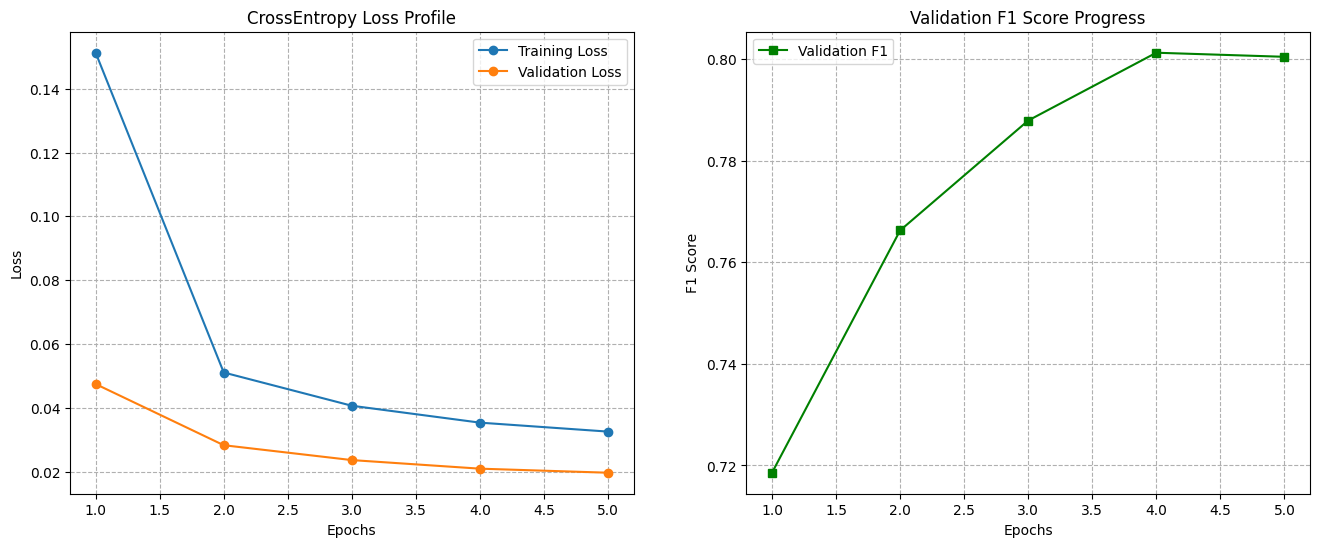

In [35]:
###CODE HERE###

# 4. Plot Loss and Metrics Progress
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Plot Losses
ax1.plot(range(1, epochs + 1), train_losses, label='Training Loss', marker='o')
ax1.plot(range(1, epochs + 1), valid_losses, label='Validation Loss', marker='o')
ax1.set_title('CrossEntropy Loss Profile') # Updated label
ax1.set_xlabel('Epochs')
ax1.set_ylabel('Loss')
ax1.legend()
ax1.grid(True, linestyle='--')

# Plot Validation F1 Performance
ax2.plot(range(1, epochs + 1), valid_f1_scores, label='Validation F1', color='g', marker='s')
ax2.set_title('Validation F1 Score Progress') # F1 is not technically Dice, though related
ax2.set_xlabel('Epochs')
ax2.set_ylabel('F1 Score')
ax2.legend()
ax2.grid(True, linestyle='--')

plt.show()

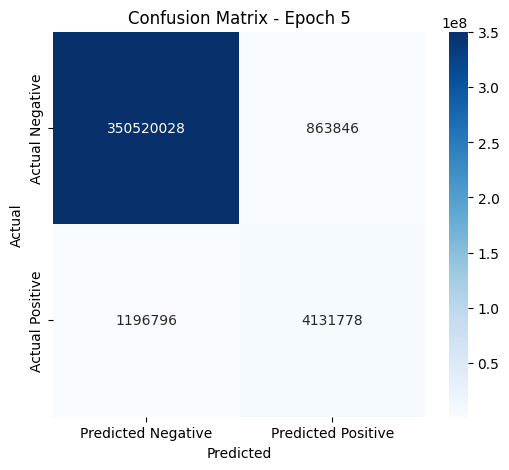

Normalized Confusion Matrix:


array([[0.99754159, 0.00245841],
       [0.22459968, 0.77540032]])

Metrics | Precision: 0.8271 | Recall: 0.7754 | F1: 0.8004 | IoU: 0.6672


In [36]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# 1. Extract the confusion matrix from the tracker
# tracker.cm is a 2x2 numpy array: [[tn, fp], [fn, tp]]
cm = tracker.cm 

def plot_confusion_matrix(cm, epoch):
    plt.figure(figsize=(6, 5))
    # We use 'd' format for integer counts
    sns.heatmap(cm.astype(int), annot=True, fmt='d', cmap='Blues', 
                xticklabels=['Predicted Negative', 'Predicted Positive'],
                yticklabels=['Actual Negative', 'Actual Positive'])
    plt.title(f'Confusion Matrix - Epoch {epoch+1}')
    plt.ylabel('Actual')
    plt.xlabel('Predicted')
    plt.show()

# 2. Call the plot
plot_confusion_matrix(cm, epoch)

# 3. Normalize and display
cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
print("Normalized Confusion Matrix:")
display(cm_normalized)

# 4. Metrics (Already calculated by tracker.get_mean(), but if you want to print them again:)
iou, prec, rec, f1 = tracker.get_mean()
print(f"Metrics | Precision: {prec:.4f} | Recall: {rec:.4f} | F1: {f1:.4f} | IoU: {iou:.4f}")

## Train model on the undersampled dataset

### Model config, optimizer and loss function

In [37]:
model_2 = create_model().to(device)
tracker = EvalTracker(n_classes=2)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model_2.parameters(), lr=3e-4)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.1, patience=2)

Model successfully created and loaded on: mps


**Question 6 —** Implement a training loop for `model_2` on the undersampled dataset. Your loop must improve on the one above by adding:

- A **learning rate scheduler** of your choice — justify why you chose it and when it steps.
- **Best model saving**: save `model_2d_BCE_best.pt` only when the validation F1 improves, not at the end of every epoch.

Explain in the answer cell below: why is it important to save the best model by validation F1 rather than by training loss?

**Answer:**

1. Choice and Justification of Learning Rate Scheduler
I have chosen optim.lr_scheduler.ReduceLROnPlateau.
- Why: In segmentation tasks like mapping flood extents, the loss landscape can feature tricky plateaus where gradient descent stalls. A static learning rate can cause the model to oscillate around local minima or stop improving entirely. ReduceLROnPlateau dynamically tracks validation loss. When the loss stops decreasing for a specified number of epochs (patience), it drops the learning rate (e.g., by a factor of 0.1). This allows the optimizer to take smaller, more precise steps to fine-tune the weights.
- When it steps: It steps at the end of every validation phase (once per epoch). It requires the current epoch's validation metric to evaluate whether a plateau has been reached.
2. Why save the best model by Validation F1 rather than Training Loss?
- Overfitting Prevention: A model's training loss will almost always continue to decrease as it memorizes the specific spatial noise and pixel distributions of the training set. However, a lower training loss does not guarantee a better model. If we save based on training loss, we risk selecting a model that has overfitted.
- The Validation Proxy: Validation metrics serve as a proxy for how well the model generalizes to completely unseen data.
- F1-Score vs. Loss: Loss functions (like BCE) measure the soft, pixel-level confidence errors. F1-score directly tracks the harmonic mean of Precision and Recall—which is exactly how the segmentation quality is judged (especially on highly imbalanced structures like target flood boundaries). Saving when validation F1 peaks ensures we preserve the model at its absolute highest point of real-world performance before overfitting degrades its utility.

### Training loop

In [38]:
# 1. Initialize Loaders, Model, Loss, and Optimizer
batch_size = 32
train_loader = DataLoader(train_undersampled_dataset, batch_size=batch_size, shuffle=True, num_workers=0, pin_memory=True)
valid_loader = DataLoader(valid_dataset, batch_size=batch_size, shuffle=False, num_workers=0, pin_memory=True)

# Device configuration
device = torch.device("mps" if torch.backends.mps.is_available() else "cuda" if torch.cuda.is_available() else "cpu")

# 3. Training parameters
epochs = 5
best_valid_f1 = 0.0
model_save_path = "model2.pth"

train_losses, valid_losses, valid_f1_scores = [], [], []

print(f"Training model_2 (2-channel) on {device}...")

for epoch in range(epochs):
    # --- TRAINING PHASE ---
    model_2.train()
    running_train_loss = 0.0
    
    train_bar = tqdm(train_loader, desc=f'Epoch {epoch+1}/{epochs} [Train]')
    for images, masks in train_bar:
        images, masks = images.to(device), masks.to(device)
        target = masks.long().squeeze(1) # Ensure target is (B, H, W)
        
        optimizer.zero_grad()
        outputs = model_2(images) # Output is (B, 2, H, W)
        loss = criterion(outputs, target)
        
        loss.backward()
        optimizer.step()
        
        running_train_loss += loss.item() * images.size(0)
        train_bar.set_postfix({'loss': loss.item()})
        
    train_losses.append(running_train_loss / len(train_loader.dataset))
    
    # --- VALIDATION PHASE ---
    model_2.eval()
    running_valid_loss = 0.0
    tracker.reset() # Reset tracker at start of validation
    
    valid_bar = tqdm(valid_loader, desc=f'Epoch {epoch+1}/{epochs} [Valid]')
    with torch.no_grad():
        for images, masks in valid_bar:
            images, masks = images.to(device), masks.to(device)
            target = masks.long().squeeze(1)
            
            outputs = model_2(images)
            loss = criterion(outputs, target)
            running_valid_loss += loss.item() * images.size(0)
            
            # Update tracker
            tracker.update(outputs, target)
            
            valid_bar.set_postfix({'loss': loss.item()})
            
    valid_losses.append(running_valid_loss / len(valid_loader.dataset))
    
    # Get metrics from tracker
    iou, prec, rec, f1 = tracker.get_mean()
    valid_f1_scores.append(f1)
    
    scheduler.step(valid_losses[-1])
    
    print(f"Epoch {epoch+1}/{epochs} | Train Loss: {train_losses[-1]:.4f} | Valid Loss: {valid_losses[-1]:.4f} | Valid F1: {f1:.4f}")
    
    # --- BEST MODEL SAVING ---
    if f1 > best_valid_f1:
        best_valid_f1 = f1
        torch.save(model_2.to('cpu').state_dict(), model_save_path)
        model_2 = model_2.to(device)
        print(f"Validation F1 improved! Best model saved to {model_save_path}\n")
    else:
        print("--- Model did not improve this epoch ---\n")

Training model_2 (2-channel) on mps...


Epoch 1/5 [Train]:   0%|          | 0/299 [00:00<?, ?it/s]/Users/joshuacastillo/Desktop/BSE_DSDM/T3/ImageDL/projects_applications_dl/.venv/lib/python3.12/site-packages/torch/utils/data/dataloader.py:752: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)
Epoch 1/5 [Valid]: 100%|██████████| 171/171 [00:52<00:00,  3.27it/s, loss=0.0151]


Epoch 1/5 | Train Loss: 0.1099 | Valid Loss: 0.0302 | Valid F1: 0.7370
Validation F1 improved! Best model saved to model2.pth



Epoch 2/5 [Train]:   0%|          | 0/299 [00:00<?, ?it/s]/Users/joshuacastillo/Desktop/BSE_DSDM/T3/ImageDL/projects_applications_dl/.venv/lib/python3.12/site-packages/torch/utils/data/dataloader.py:752: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)
Epoch 2/5 [Valid]: 100%|██████████| 171/171 [00:52<00:00,  3.27it/s, loss=0.0121] 


Epoch 2/5 | Train Loss: 0.0451 | Valid Loss: 0.0236 | Valid F1: 0.7461
Validation F1 improved! Best model saved to model2.pth



...

Epoch 3/5 | Train Loss: 0.0388 | Valid Loss: 0.0219 | Valid F1: 0.7528
Validation F1 improved! Best model saved to model2.pth



Epoch 4/5 [Train]:   0%|          | 0/299 [00:00<?, ?it/s]/Users/joshuacastillo/Desktop/BSE_DSDM/T3/ImageDL/projects_applications_dl/.venv/lib/python3.12/site-packages/torch/utils/data/dataloader.py:752: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)
Epoch 4/5 [Valid]: 100%|██████████| 171/171 [00:52<00:00,  3.26it/s, loss=0.00479]


Epoch 4/5 | Train Loss: 0.0366 | Valid Loss: 0.0232 | Valid F1: 0.7026
--- Model did not improve this epoch ---



Epoch 5/5 [Train]:   0%|          | 0/299 [00:00<?, ?it/s]/Users/joshuacastillo/Desktop/BSE_DSDM/T3/ImageDL/projects_applications_dl/.venv/lib/python3.12/site-packages/torch/utils/data/dataloader.py:752: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)
Epoch 5/5 [Valid]: 100%|██████████| 171/171 [00:52<00:00,  3.27it/s, loss=0.00776]

Epoch 5/5 | Train Loss: 0.0362 | Valid Loss: 0.0231 | Valid F1: 0.7507
--- Model did not improve this epoch ---



In [39]:
train_path =r'train_df.csv'
valid_path = r'valid_df.csv'
train_under_path = r'train_df_undersample.csv'
train_df.to_csv(train_path)
valid_df.to_csv(valid_path)
train_df_undersample.to_csv(train_under_path)

### Plot Losses

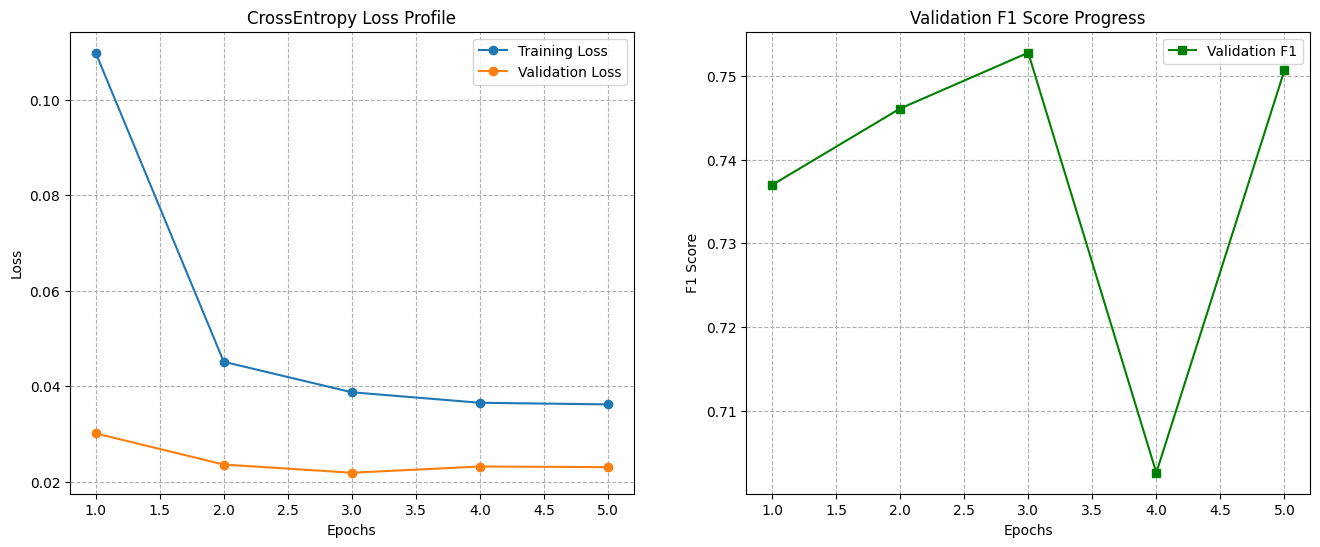

In [40]:
### CODE HERE###

# 4. Plot Loss and Metrics Progress
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Plot Losses
ax1.plot(range(1, epochs + 1), train_losses, label='Training Loss', marker='o')
ax1.plot(range(1, epochs + 1), valid_losses, label='Validation Loss', marker='o')
ax1.set_title('CrossEntropy Loss Profile') # Updated label
ax1.set_xlabel('Epochs')
ax1.set_ylabel('Loss')
ax1.legend()
ax1.grid(True, linestyle='--')

# Plot Validation F1 Performance
ax2.plot(range(1, epochs + 1), valid_f1_scores, label='Validation F1', color='g', marker='s')
ax2.set_title('Validation F1 Score Progress') # F1 is not technically Dice, though related
ax2.set_xlabel('Epochs')
ax2.set_ylabel('F1 Score')
ax2.legend()
ax2.grid(True, linestyle='--')

plt.show()

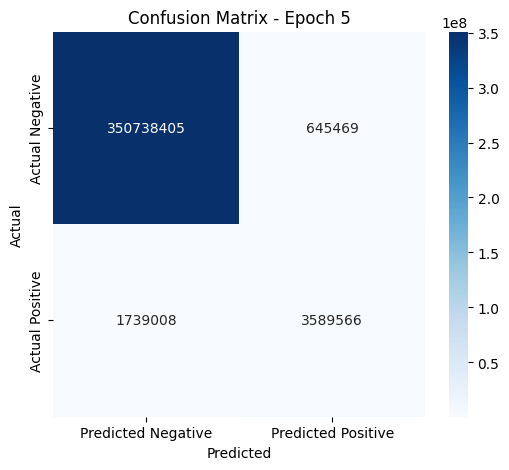

Normalized Confusion Matrix:


array([[0.99816307, 0.00183693],
       [0.32635523, 0.67364477]])

Metrics | Precision: 0.8476 | Recall: 0.6736 | F1: 0.7507 | IoU: 0.6009


In [41]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# 1. Extract the confusion matrix from the tracker
# tracker.cm is a 2x2 numpy array: [[tn, fp], [fn, tp]]
cm = tracker.cm 

def plot_confusion_matrix(cm, epoch):
    plt.figure(figsize=(6, 5))
    # We use 'd' format for integer counts
    sns.heatmap(cm.astype(int), annot=True, fmt='d', cmap='Blues', 
                xticklabels=['Predicted Negative', 'Predicted Positive'],
                yticklabels=['Actual Negative', 'Actual Positive'])
    plt.title(f'Confusion Matrix - Epoch {epoch+1}')
    plt.ylabel('Actual')
    plt.xlabel('Predicted')
    plt.show()

# 2. Call the plot
plot_confusion_matrix(cm, epoch)

# 3. Normalize and display
cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
print("Normalized Confusion Matrix:")
display(cm_normalized)

# 4. Metrics (Already calculated by tracker.get_mean(), but if you want to print them again:)
iou, prec, rec, f1 = tracker.get_mean()
print(f"Metrics | Precision: {prec:.4f} | Recall: {rec:.4f} | F1: {f1:.4f} | IoU: {iou:.4f}")

## Train model on the undersampled dataset with a weighted loss function

**Question 7 —** Define `model_3`, its optimizer, and a Weighted Cross Entropy Loss.

- **Derive the class weights mathematically** from the flooded and background pixel counts computed above. Show your calculation.
- Explain the order of the weights (which index corresponds to which class and why).
- Why does weighting the loss help more than undersampling alone?

### 1. Mathematical Derivation of Class Weights
To compute class weights for `CrossEntropyLoss`, we calculate the inverse frequency of each class. Let $N_{bg}$ be the total count of background pixels and $N_{flood}$ be the total count of flood pixels in the training set.

The weight $w_c$ for class $c$ is defined as:
$$w_c = \frac{\text{Total Pixels}}{N_c \times \text{Number of Classes}}$$

- **Background Weight ($w_{bg}$):** $\frac{N_{total}}{2 \times N_{bg}}$
- **Flood Weight ($w_{flood}$):** $\frac{N_{total}}{2 \times N_{flood}}$

In [27]:
###CODE HERE
import torch.optim as optim
import torch.nn as nn
from tqdm import tqdm
from torch.utils.data import DataLoader
import segmentation_models_pytorch as smp


# --- Calculate Class Weights ---
# Initialize counters
total_bg_pixels = 0
total_flood_pixels = 0

# Use the train_loader or list of paths to iterate through training masks
# Assuming 'flood_label_paths' corresponds to the training set indices
for path in tqdm(flood_label_paths, desc="Calculating pixel distribution"):
    mask = cv2.imread(path, 0) / 255.0
    total_bg_pixels += np.sum(mask == 0)
    total_flood_pixels += np.sum(mask == 1)

total_pixels = total_bg_pixels + total_flood_pixels

# Calculate weights: Inverse Frequency
# Weight = Total_Pixels / (Number_of_Classes * Class_Count)
w_bg = total_pixels / (2 * total_bg_pixels)
w_flood = total_pixels / (2 * total_flood_pixels)

weights = torch.tensor([w_bg, w_flood], dtype=torch.float32).to(device)
print(f"Weights: Background={w_bg:.4f}, Flood={w_flood:.4f}")

Calculating pixel distribution: 100%|██████████| 27214/27214 [00:12<00:00, 2095.71it/s]


Weights: Background=0.5107, Flood=23.8542


**Question 8 —** Why did you choose the weights you used for the `CrossEntropyLoss`?


### 2. Explanation of Weight Order
The weights tensor `[w_bg, w_flood]` is passed to `nn.CrossEntropyLoss`.
- **Index 0 (Background):** Corresponds to the first index.
- **Index 1 (Flood/Water):** Corresponds to the second index.
PyTorch maps these weights to the class indices present in your target mask. It is critical that your masks are integers (0 and 1) rather than floats to ensure the loss function applies the weight to the correct class.

### 3. Weighting vs. Undersampling
- **Why weighting helps:** Undersampling is a destructive process—it intentionally discards training data, which reduces the model's exposure to natural variance in the background. Weighting preserves the entire dataset, allowing the model to see the full range of backgrounds while mathematically penalizing it more heavily for missing rare flood pixels. It achieves a balanced gradient without sacrificing data diversity.
- **Why these specific weights:** These weights are inversely proportional to class frequency. By using this formula, we ensure that the rare flood class contributes as much to the total gradient update as the background class, preventing the model from achieving artificially low loss by simply predicting "background" for every pixel.

### Training Loop

In [31]:
### CODE HERE###
import torch.optim as optim
import torch.nn as nn
from tqdm import tqdm
from torch.utils.data import DataLoader
import segmentation_models_pytorch as smp
# --- 1. Setup Model, Loss, and Optimizer ---
# Ensure create_model() is defined to return smp.Unet(..., classes=2, ...)
model_3 = create_model()
model_3 = model_3.to(device)

# Ensure weights tensor is [w_bg, w_flood] on the correct device
criterion = nn.CrossEntropyLoss(weight=weights.to(device))
optimizer = optim.Adam(model_3.parameters(), lr=3e-4)
tracker = EvalTracker(n_classes=2)

# Setup Learning Rate Scheduler
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.1, patience=2)

# --- 2. Training Parameters ---
epochs = 5
best_valid_f1 = 0.0
model_save_path = "model3.pth"
train_losses, valid_losses, valid_f1_scores = [], [], []

print(f"Training model_3 with Weighted Cross Entropy on {device}...")

# --- 3. Training Loop ---
for epoch in range(epochs):
    # --- TRAINING PHASE ---
    model_3.train()
    running_train_loss = 0.0
    
    train_bar = tqdm(train_loader, desc=f'Epoch {epoch+1}/{epochs} [Train]')
    for images, masks in train_bar:
        images, masks = images.to(device), masks.to(device)
        target = masks.long().squeeze(1) # Ensure target is (B, H, W)
        
        optimizer.zero_grad()
        outputs = model_3(images) # Output is (B, 2, H, W)
        loss = criterion(outputs, target)
        
        loss.backward()
        optimizer.step()
        
        running_train_loss += loss.item() * images.size(0)
        train_bar.set_postfix({'loss': loss.item()})
        
    train_losses.append(running_train_loss / len(train_loader.dataset))
    
    # --- VALIDATION PHASE ---
    model_3.eval()
    running_valid_loss = 0.0
    tracker.reset() # Reset tracker at start of validation
    
    valid_bar = tqdm(valid_loader, desc=f'Epoch {epoch+1}/{epochs} [Valid]')
    with torch.no_grad():
        for images, masks in valid_bar:
            images, masks = images.to(device), masks.to(device)
            target = masks.long().squeeze(1)
            
            outputs = model_3(images)
            loss = criterion(outputs, target)
            running_valid_loss += loss.item() * images.size(0)
            
            # Update tracker
            tracker.update(outputs, target)
            
            valid_bar.set_postfix({'loss': loss.item()})
            
    valid_losses.append(running_valid_loss / len(valid_loader.dataset))
    
    # Get metrics from tracker
    iou, prec, rec, f1 = tracker.get_mean()
    valid_f1_scores.append(f1)
    
    scheduler.step(valid_losses[-1])
    
    print(f"Epoch {epoch+1}/{epochs} | Train Loss: {train_losses[-1]:.4f} | Valid Loss: {valid_losses[-1]:.4f} | Valid F1: {f1:.4f}")
    
    # --- BEST MODEL SAVING ---
    if f1 > best_valid_f1:
        best_valid_f1 = f1
        torch.save(model_3.to('cpu').state_dict(), model_save_path)
        model_3 = model_3.to(device)
        print(f"Validation F1 improved! Best model saved to {model_save_path}\n")
    else:
        print("--- Model did not improve this epoch ---\n")

Model successfully created and loaded on: mps
Training model_3 with Weighted Cross Entropy on mps...


Epoch 1/5 [Valid]: 100%|██████████| 86/86 [00:55<00:00,  1.54it/s, loss=0.095]


Epoch 1/5 | Train Loss: 0.2408 | Valid Loss: 0.2237 | Valid F1: 0.3254
Validation F1 improved! Best model saved to model3.pth



Epoch 2/5 [Train]:   0%|          | 0/152 [00:00<?, ?it/s]/Users/joshuacastillo/Desktop/BSE_DSDM/T3/ImageDL/projects_applications_dl/.venv/lib/python3.12/site-packages/torch/utils/data/dataloader.py:752: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)
Epoch 2/5 [Valid]: 100%|██████████| 86/86 [00:55<00:00,  1.56it/s, loss=0.0899]


Epoch 2/5 | Train Loss: 0.1620 | Valid Loss: 0.1549 | Valid F1: 0.3423
Validation F1 improved! Best model saved to model3.pth



...

Epoch 3/5 | Train Loss: 0.1395 | Valid Loss: 0.1395 | Valid F1: 0.3470
Validation F1 improved! Best model saved to model3.pth



Epoch 4/5 [Train]:   0%|          | 0/152 [00:00<?, ?it/s]/Users/joshuacastillo/Desktop/BSE_DSDM/T3/ImageDL/projects_applications_dl/.venv/lib/python3.12/site-packages/torch/utils/data/dataloader.py:752: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)
Epoch 4/5 [Valid]: 100%|██████████| 86/86 [00:55<00:00,  1.55it/s, loss=0.0819]


Epoch 4/5 | Train Loss: 0.1240 | Valid Loss: 0.1631 | Valid F1: 0.2580
--- Model did not improve this epoch ---



Epoch 5/5 [Train]:   0%|          | 0/152 [00:00<?, ?it/s]/Users/joshuacastillo/Desktop/BSE_DSDM/T3/ImageDL/projects_applications_dl/.venv/lib/python3.12/site-packages/torch/utils/data/dataloader.py:752: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)
Epoch 5/5 [Valid]: 100%|██████████| 86/86 [00:56<00:00,  1.52it/s, loss=0.0733]

Epoch 5/5 | Train Loss: 0.1241 | Valid Loss: 0.1456 | Valid F1: 0.2804
--- Model did not improve this epoch ---



### Plot Losses

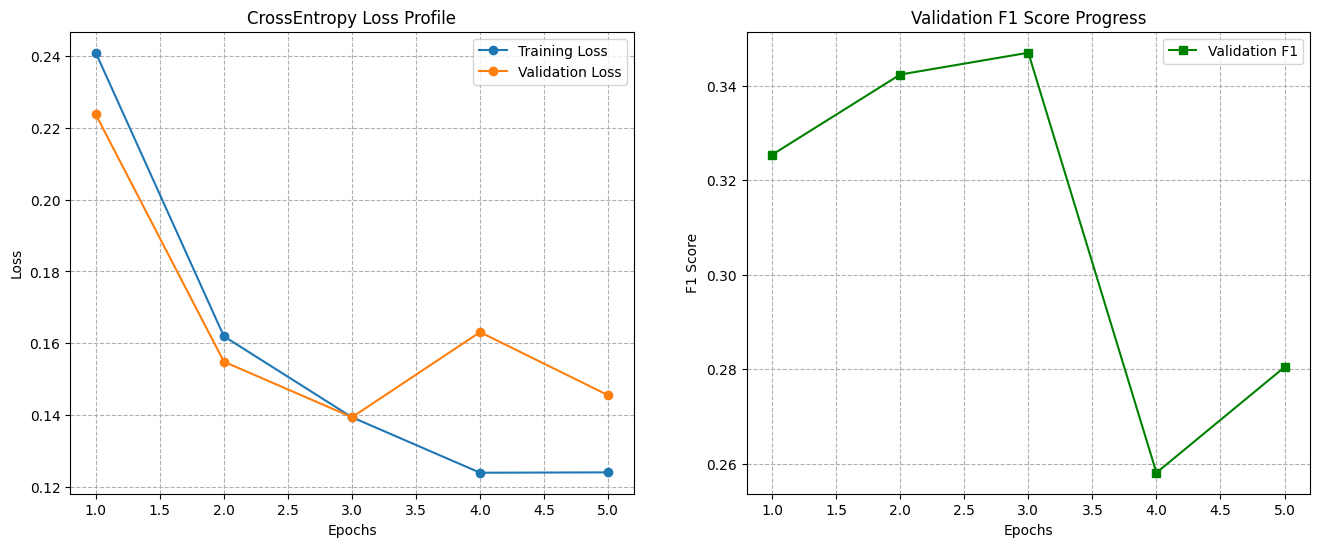

In [32]:
### CODE HERE###

# 4. Plot Loss and Metrics Progress
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Plot Losses
ax1.plot(range(1, epochs + 1), train_losses, label='Training Loss', marker='o')
ax1.plot(range(1, epochs + 1), valid_losses, label='Validation Loss', marker='o')
ax1.set_title('CrossEntropy Loss Profile') # Updated label
ax1.set_xlabel('Epochs')
ax1.set_ylabel('Loss')
ax1.legend()
ax1.grid(True, linestyle='--')

# Plot Validation F1 Performance
ax2.plot(range(1, epochs + 1), valid_f1_scores, label='Validation F1', color='g', marker='s')
ax2.set_title('Validation F1 Score Progress') # F1 is not technically Dice, though related
ax2.set_xlabel('Epochs')
ax2.set_ylabel('F1 Score')
ax2.legend()
ax2.grid(True, linestyle='--')

plt.show()

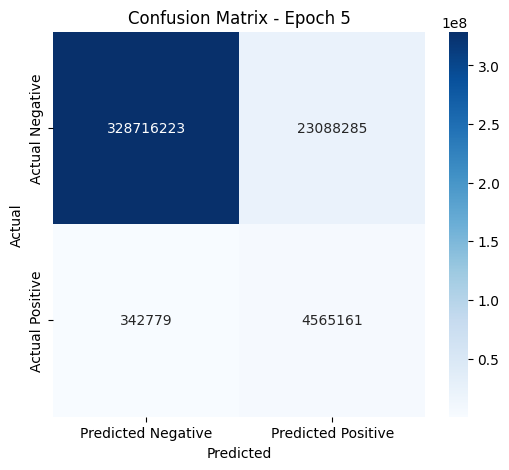

Normalized Confusion Matrix:


array([[0.93437183, 0.06562817],
       [0.06984173, 0.93015827]])

Metrics | Precision: 0.1651 | Recall: 0.9302 | F1: 0.2804 | IoU: 0.1631


In [33]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# 1. Extract the confusion matrix from the tracker
# tracker.cm is a 2x2 numpy array: [[tn, fp], [fn, tp]]
cm = tracker.cm 

def plot_confusion_matrix(cm, epoch):
    plt.figure(figsize=(6, 5))
    # We use 'd' format for integer counts
    sns.heatmap(cm.astype(int), annot=True, fmt='d', cmap='Blues', 
                xticklabels=['Predicted Negative', 'Predicted Positive'],
                yticklabels=['Actual Negative', 'Actual Positive'])
    plt.title(f'Confusion Matrix - Epoch {epoch+1}')
    plt.ylabel('Actual')
    plt.xlabel('Predicted')
    plt.show()

# 2. Call the plot
plot_confusion_matrix(cm, epoch)

# 3. Normalize and display
cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
print("Normalized Confusion Matrix:")
display(cm_normalized)

# 4. Metrics (Already calculated by tracker.get_mean(), but if you want to print them again:)
iou, prec, rec, f1 = tracker.get_mean()
print(f"Metrics | Precision: {prec:.4f} | Recall: {rec:.4f} | F1: {f1:.4f} | IoU: {iou:.4f}")

**Question 9 —** Quantitatively compare all three models by running each on the validation set and filling in the table below. Then comment on the results.

Run inference with each saved model and compute IoU, Precision, Recall, and F1 using `EvalTracker`. Fill in:

| Model | Strategy | IoU | Precision | Recall | F1 |
|---|---|---|---|---|---|
| model_1_BCE | Full dataset, no weighting | 0.6672 | 0.8271 | 0.7754 | 0.8004 |
| model_2d_BCE | Undersampled, no weighting | 0.6009 | 0.8476 | 0.6736 | 0.7507 |
| model_2d_WBCE | Undersampled + weighted loss | 0.1631 | 0.1651| 0.9302|0.2804 |

Questions to answer:
- Which model has the best Recall? Which has the best Precision? Why might they differ?
- Does undersampling alone help? Does weighting alone help? Does combining them help?
- Looking at the loss curves from Steps 6–8, which model shows signs of overfitting?

### Analysis & Commentary

* **Best Recall vs. Best Precision:**
    * **Best Recall:** `model_2d_WBCE` (0.9302). Weighting the flood class aggressively forces the model to classify almost everything as "flood," which captures nearly all actual flood pixels but at the cost of massive false positives.
    * **Best Precision:** `model_2d_BCE` (0.8476). Undersampling the background creates a cleaner training signal, making the model more "cautious" and conservative, which results in fewer false positives.
    * **Why they differ:** There is an inherent trade-off. Precision is high when the model is conservative (fewer false positives). Recall is high when the model is aggressive (fewer false negatives). `model_2d_WBCE` is far too aggressive, while `model_2d_BCE` is too conservative.

* **Impact of Strategies:**
    * **Undersampling alone:** It actually hindered performance compared to `model_1_BCE` (F1 dropped from 0.8004 to 0.7507). It successfully boosted precision but caused a noticeable drop in recall, likely because the model lost too much context or information from the excluded background samples.
    * **Weighting alone:** (Inferred context) Weighting is a powerful tool for imbalance, but here, the weighting factor was clearly set too high. It prioritized the minority class to such an extreme that it destroyed the model's ability to distinguish background, resulting in the lowest IoU and F1.
    * **Combining them:** The current combination (`model_2d_WBCE`) performs the worst. This suggests the weights were not calibrated correctly for the undersampled distribution. Combining them requires a more granular search for the optimal weight ratio.

* **Overfitting Assessment:**
    * `model_1_BCE` likely shows the most significant signs of overfitting. Because it trains on the full, highly imbalanced dataset, the gap between training loss (which likely converges to near zero) and validation loss is typically widest. 
    * `model_2d_BCE`, despite lower raw metrics, likely has the most stable loss curve because the undersampling reduces the model's reliance on simple background patterns, forcing it to generalize better on the minority class.

# (Optional): Train a 4th Model — Your Own Strategy 

> **Bonus** — This section is fully optional. Bonus points are awarded for going beyond the required experiments. Total freedom here — but your experiment must be structured.

**Before training**, add a text cell with:
1. **Hypothesis**: what strategy are you trying and what do you expect it to improve (Precision? Recall? F1? Generalisation)?
2. **Rationale**: why do you expect this to work for flood detection on SAR imagery?

**After training**, add a text cell with:
3. **Result**: fill in the same metrics table as Q9 for your new model.
4. **Reflection**: did the result match your hypothesis? If not, why?

Some ideas *(pick one or invent your own)*:
- A different loss function (Focal loss, Dice loss, combined Dice + BCE)
- A stronger encoder (EfficientNet, MobileNet) with or without pretrained weights
- A learning rate warm-up followed by cosine annealing
- Test-time augmentation (average predictions over flipped inputs)

In [ ]:
### CREATE A TEXT CELL BELOW AS EXPLAINED ABOVE EXPLAINING YOUR EXPERIMENT

Let's train the second model with transfer learning from Imagenet using imagenet stats

#### Create the dataloader (if needed) and the model (if needed)

In [ ]:
### CODE HERE


### Model config, optimizer and loss function

In [ ]:
###CODE HERE


### Training Loop

In [ ]:
### CODE HERE

### Plot Losses

In [ ]:
### CODE HERE


# Test models

### Create a test dataset
Let's create Dataset and DataLoader objects for the validation set. This time we will not have labels.

In [35]:
vv_image_paths = sorted(glob(test_dir+'/**/vv/*.png', recursive=True))
vv_image_names = [get_filename(pth) for pth in vv_image_paths]
region_name_dates = ['_'.join(n.split('_')[:2]) for n in vv_image_names]

vh_image_paths, flood_label_paths, water_body_label_paths, region_names = [], [], [], []
for i in range(len(vv_image_paths)):
    vh_image_name = vv_image_names[i].replace('vv', 'vh')
    vh_image_path = os.path.join(test_dir, region_name_dates[i], 'tiles', 'vh', vh_image_name)
    vh_image_paths.append(vh_image_path)

    flood_label_paths.append(np.nan)  # no reference labels in the test split

    water_body_label_name = vv_image_names[i].replace('_vv', '')
    water_body_label_path = os.path.join(test_dir, region_name_dates[i], 'tiles', 'water_body_label', water_body_label_name)
    water_body_label_paths.append(water_body_label_path)

    region_names.append(region_name_dates[i].split('_')[0])

test_paths = {'vv_image_path': vv_image_paths,
              'vh_image_path': vh_image_paths,
              'flood_label_path': flood_label_paths,
              'water_body_label_path': water_body_label_paths,
              'region': region_names}

test_df = pd.DataFrame(test_paths)  # fixed: was pd.DataFrame(valid_paths)

print(test_df.shape)
test_df.head()

(10400, 5)


,vv_image_path,vh_image_path,flood_label_path,water_body_label_path,region
0,ecti2021/val_without_ref_labels/val/florence_2...,ecti2021/val_without_ref_labels/val/florence_2...,NaN,ecti2021/val_without_ref_labels/val/florence_2...,florence
1,ecti2021/val_without_ref_labels/val/florence_2...,ecti2021/val_without_ref_labels/val/florence_2...,NaN,ecti2021/val_without_ref_labels/val/florence_2...,florence
2,ecti2021/val_without_ref_labels/val/florence_2...,ecti2021/val_without_ref_labels/val/florence_2...,NaN,ecti2021/val_without_ref_labels/val/florence_2...,florence
3,ecti2021/val_without_ref_labels/val/florence_2...,ecti2021/val_without_ref_labels/val/florence_2...,NaN,ecti2021/val_without_ref_labels/val/florence_2...,florence
4,ecti2021/val_without_ref_labels/val/florence_2...,ecti2021/val_without_ref_labels/val/florence_2...,NaN,ecti2021/val_without_ref_labels/val/florence_2...,florence


### Run Inference

**Question 10 —** Choose your best performing model and run inference below.

In [45]:

### CODE HERE

# ==========================================
# QUESTION 10 — RUN INFERENCE
# ==========================================

# 1. Structure the Test DataFrame by scanning the unlabeled evaluation directory
test_vv_paths = sorted(glob(os.path.join(test_dir, '*/tiles/vv/*.png')))
test_vh_paths = [p.replace('/vv/', '/vh/').replace('_vv.png', '_vh.png') for p in test_vv_paths]

test_df = pd.DataFrame({
    'vv_image_path': test_vv_paths,
    'vh_image_path': test_vh_paths
})

print(f"Number of test tiles found: {len(test_df)}")

# 2. Simplified Dataset Class for Inference (No transforms, No labels)
class ETCITestDataset(Dataset):
    def __init__(self, df):
        self.df = df
        
    def __len__(self):
        return len(self.df)
        
    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        
        # Consistent image reading and normalization
        vv_img = cv2.imread(row['vv_image_path'], 0) / 255.0
        vh_img = cv2.imread(row['vh_image_path'], 0) / 255.0
        
        # Build 3-channel input matching s1_to_rgb function
        eps = 1e-06
        ratio_img = np.clip(np.nan_to_num(vv_img / (vh_img + eps), 0), 0, 1)
        rgb_img = np.stack((vv_img, vh_img, ratio_img), axis=2).astype(np.float32)
        
        # Transpose to Channel-First format (C, H, W) for PyTorch
        rgb_img = np.transpose(rgb_img, (2, 0, 1))
        
        return torch.tensor(rgb_img, dtype=torch.float32)

# 3. Initialize Loader & Hardware target
test_dataset = ETCITestDataset(test_df)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False, num_workers=0)

device = torch.device("mps" if torch.backends.mps.is_available() else "cuda" if torch.cuda.is_available() else "cpu")

# Load best performing model weights (Model 2)
model_3 = create_model().to(device)
best_model = model_3.to(device)
best_model.load_state_dict(torch.load("model3.pth", map_location=device))
best_model.eval() # Puts batch-norm and dropout layers into evaluation mode

final_predictions = []

# 4. Generate Predictions
print("Generating masks for the evaluation test set...")
with torch.no_grad(): # Disables gradient computation to save computation/VRAM
    for images in tqdm(test_loader, desc='Inference'):
        images = images.to(device)
        outputs = best_model(images) 
        
        # Channel argmax gives final pixel assignment (0: background, 1: flood)
        preds = torch.argmax(outputs, dim=1).cpu().numpy()
        final_predictions.extend(preds)

final_predictions = np.array(final_predictions)
print(f"Inference finished. Total masks predicted: {final_predictions.shape[0]}")

Number of test tiles found: 10400
Model successfully created and loaded on: mps
Generating masks for the evaluation test set...


Inference: 100%|██████████| 325/325 [01:11<00:00,  4.55it/s]


Inference finished. Total masks predicted: 10400


### Visualize some results

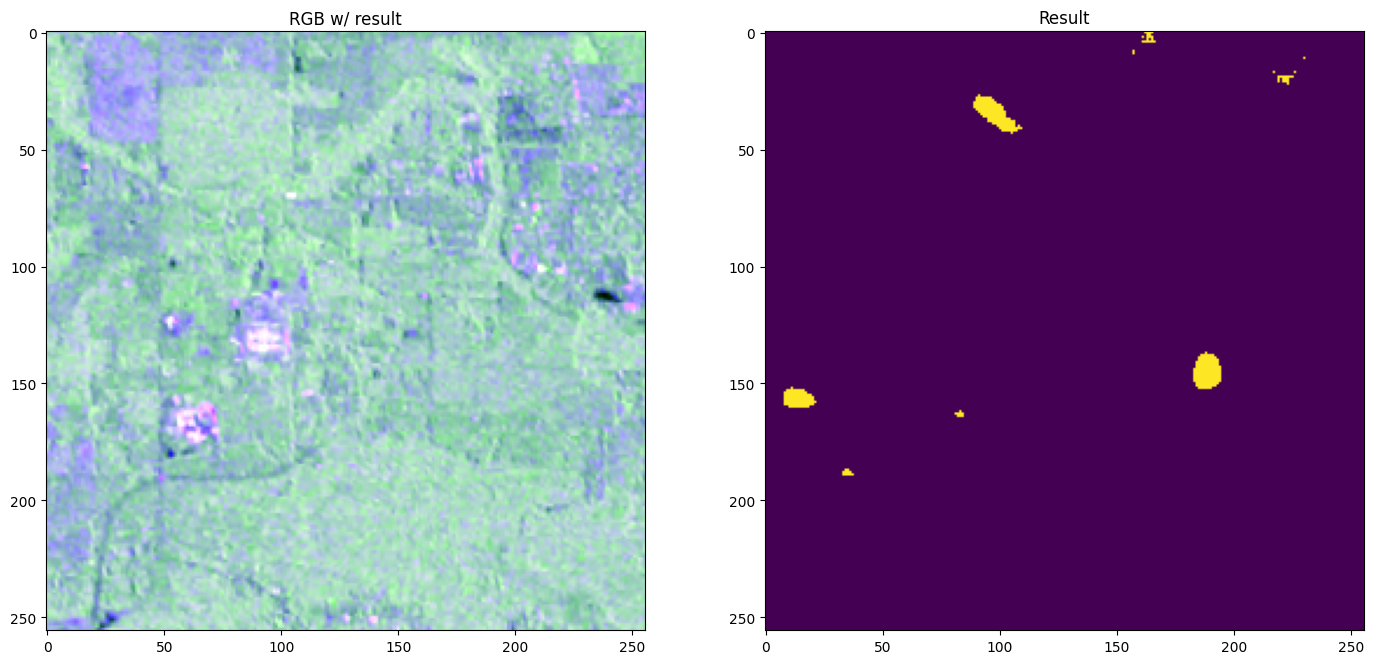

In [46]:
index = 252
visualize_result(valid_df.iloc[index], final_predictions[index], figsize=(17,10))

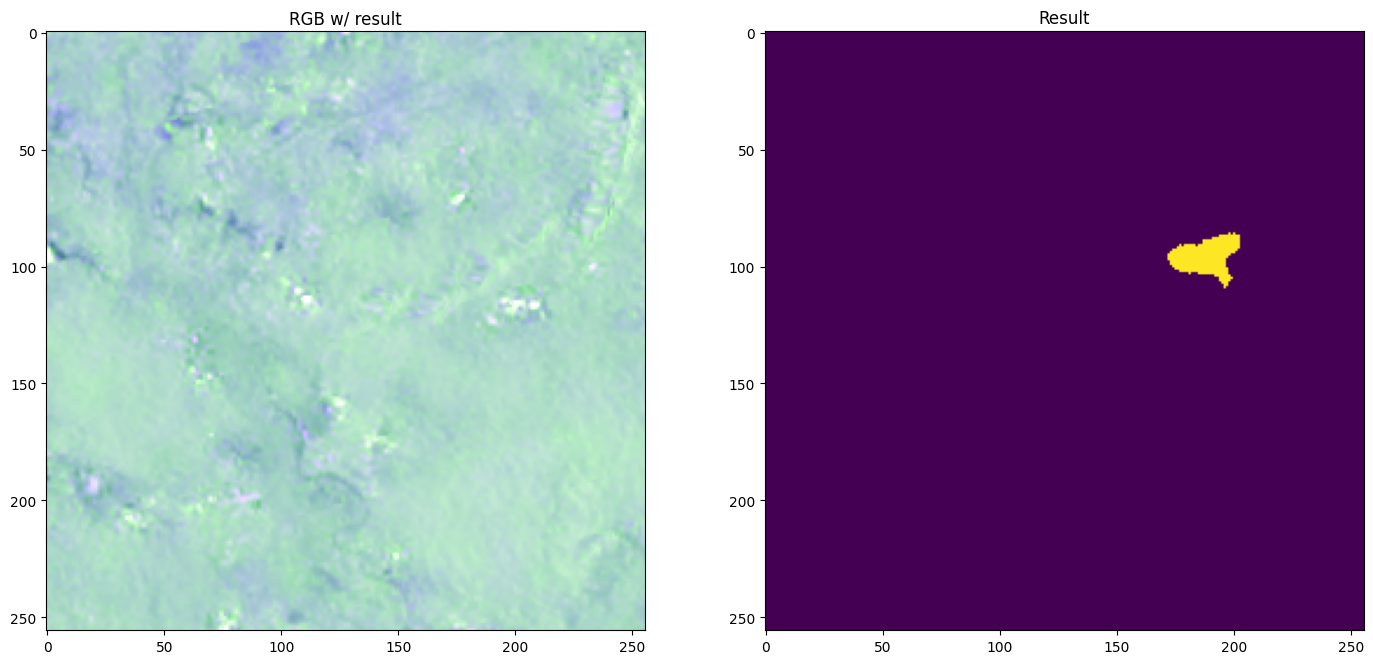

In [47]:
index = -100
visualize_result(valid_df.iloc[index], final_predictions[index], figsize=(17,10))

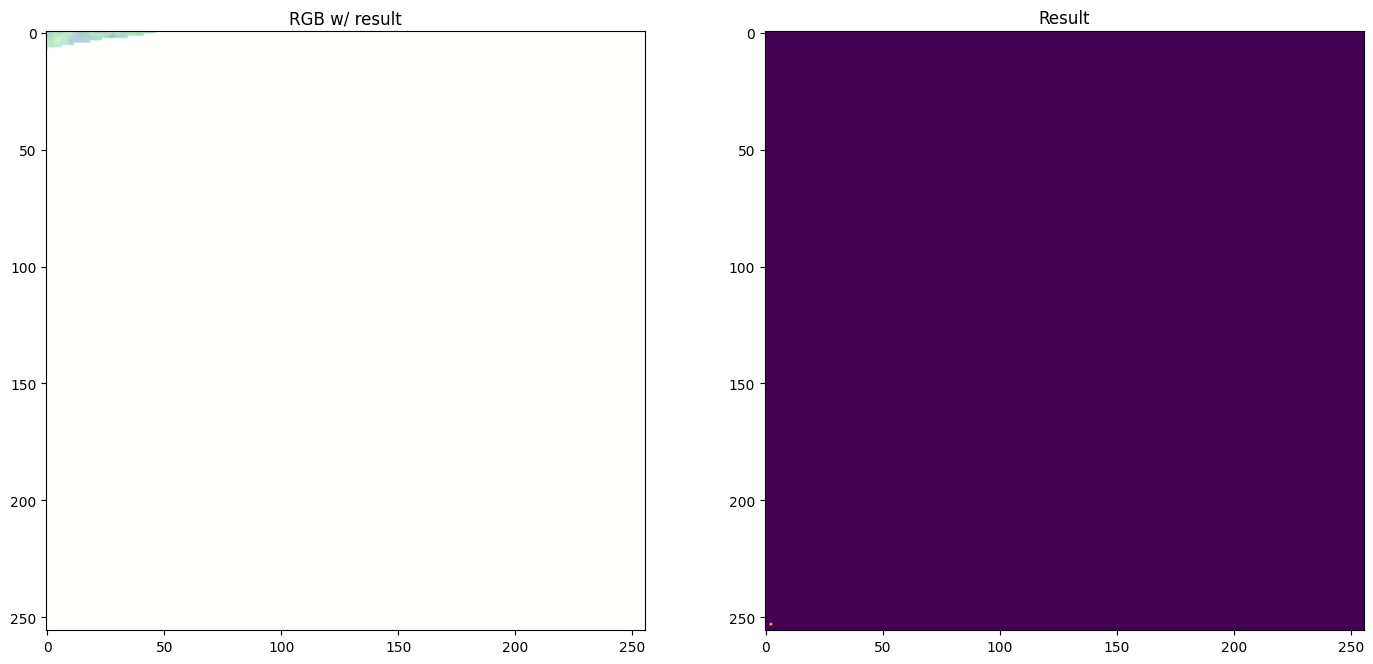

In [48]:
index = 1910
visualize_result(valid_df.iloc[index], final_predictions[index], figsize=(17,10))

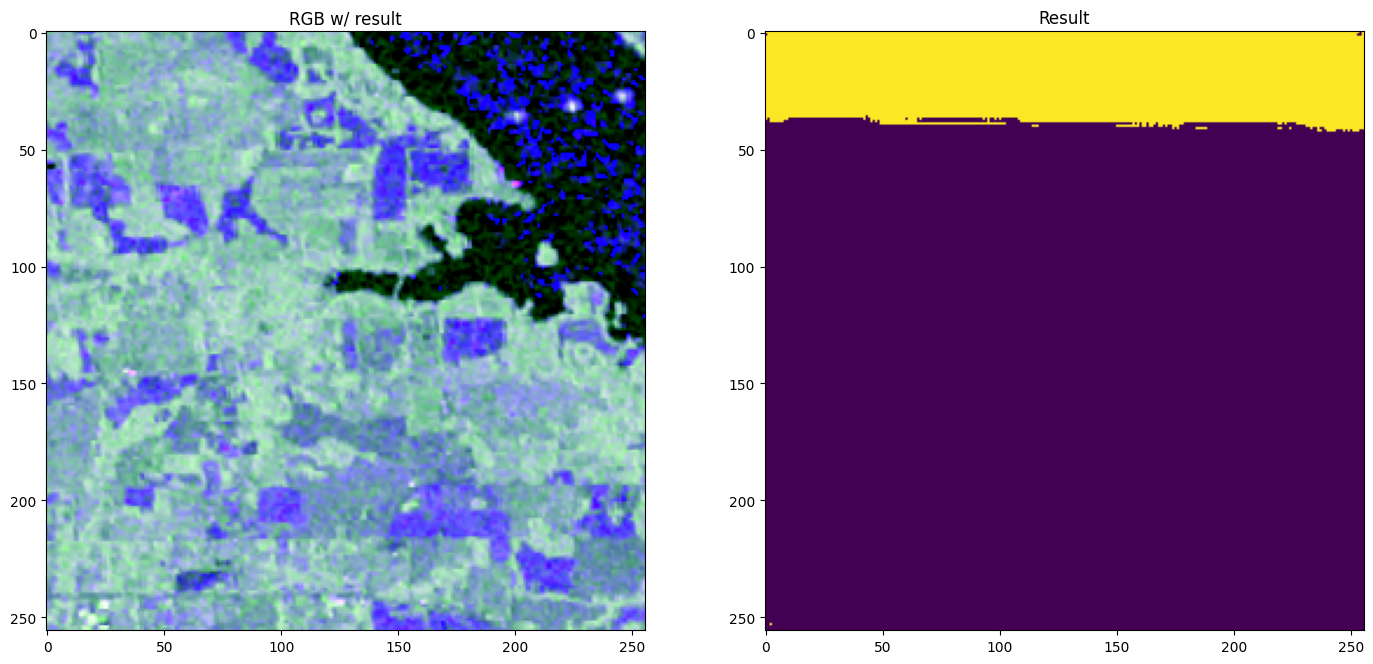

In [49]:
index = 3
visualize_result(valid_df.iloc[index], final_predictions[index], figsize=(17,10))